# Assignment: Reading and Visualizing Images in Python

**Course:** Introduction to Image Processing / Computer Vision  
**Date:** 2026-02-27

---

## Learning Objectives
- Read images using different Python libraries
- Understand differences between image formats and data types
- Convert between color spaces
- Visualize and process images using NumPy-based tools

## 0) Environment Setup

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from PIL import Image
from skimage import io
from skimage.util import img_as_float

print("OpenCV:", cv2.__version__)

IMAGE_PATH = "img.jpg"

OpenCV: 4.13.0


## Part 1: Using PIL (Pillow)

PIL loads images as **PIL Image objects**, not NumPy arrays.

Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Image size: (625, 350)
Image mode: RGB


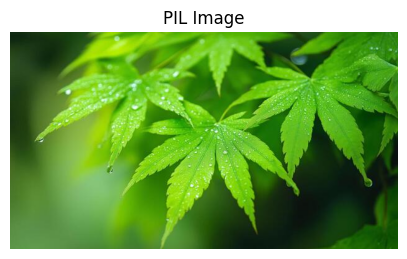

In [4]:

pil_img = Image.open(IMAGE_PATH)
print("Image type:", type(pil_img))
print("Image size:", pil_img.size)
print("Image mode:", pil_img.mode)

plt.figure(figsize=(5,5))
plt.imshow(pil_img)
plt.title("PIL Image")
plt.axis('off')
plt.show()

### Task 1.1: PIL → NumPy Conversion

In [5]:

img_array = np.array(pil_img)
print("Array shape:", img_array.shape)
print("Array dtype:", img_array.dtype)

Array shape: (350, 625, 3)
Array dtype: uint8


## Part 2: Matplotlib Image Reading

Matplotlib reads images directly as NumPy arrays.

Image shape: (350, 625, 3)


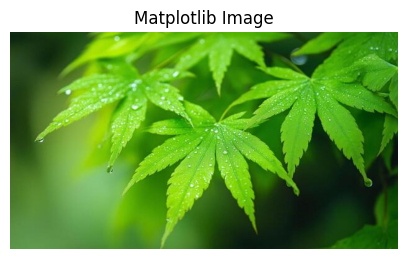

In [6]:
# TODO 3:
# 1. Read the image using matplotlib.image.imread
# 2. Print its shape
# 3. Display it using plt.imshow

mpl_img = mpimg.imread(IMAGE_PATH)
print("Image shape:", mpl_img.shape)

plt.figure(figsize=(5,5))
plt.imshow(mpl_img)
plt.title("Matplotlib Image")
plt.axis('off')
plt.show()

### Concept Question
**Q:** Why does Matplotlib treat images as NumPy arrays?

**A:** Matplotlib treats images as NumPy arrays because NumPy provides efficient numerical operations and easy manipulation of multi-dimensional data, making it ideal for image processing and visualization.

## Part 3: scikit-image

scikit-image works with well-defined data ranges.

Min pixel value: 0.0
Max pixel value: 1.0


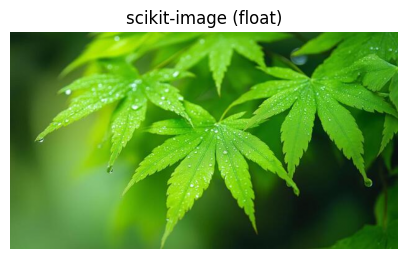

In [7]:
# TODO 4:
# 1. Read the image using skimage.io.imread
# 2. Convert it to float using img_as_float
# 3. Print min and max pixel values
# 4. Display the image

sk_img = io.imread(IMAGE_PATH)
sk_img_float = img_as_float(sk_img)

print("Min pixel value:", sk_img_float.min())
print("Max pixel value:", sk_img_float.max())

plt.figure(figsize=(5,5))
plt.imshow(sk_img_float)
plt.title("scikit-image (float)")
plt.axis('off')
plt.show()

### Task 3.1: Data Type Exploration

**Q:** Why is using `astype(float)` discouraged compared to `img_as_float`?

**A:** `img_as_float` properly scales the pixel values to [0,1] range while preserving the image's dynamic range, whereas `astype(float)` simply converts the data type without proper scaling, which can lead to incorrect values (e.g., 255 becomes 255.0 instead of 1.0).

## Part 4: OpenCV

⚠️ OpenCV loads color images in **BGR** format.

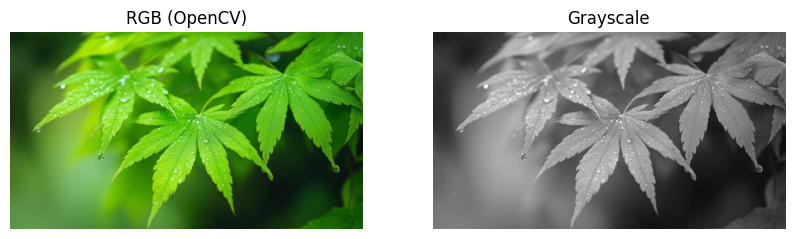

In [8]:
# TODO 5:
# 1. Read the image in grayscale and color using OpenCV
# 2. Convert the color image from BGR to RGB
# 3. Display the RGB image using matplotlib

img_cv_color = cv2.imread(IMAGE_PATH, cv2.IMREAD_COLOR)
img_cv_gray = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

img_cv_rgb = cv2.cvtColor(img_cv_color, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(img_cv_rgb); plt.title("RGB (OpenCV)"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(img_cv_gray, cmap='gray'); plt.title("Grayscale"); plt.axis('off')
plt.show()

### Task 4.1: Image Processing

Apply **Canny edge detection** on the grayscale image and display the result.

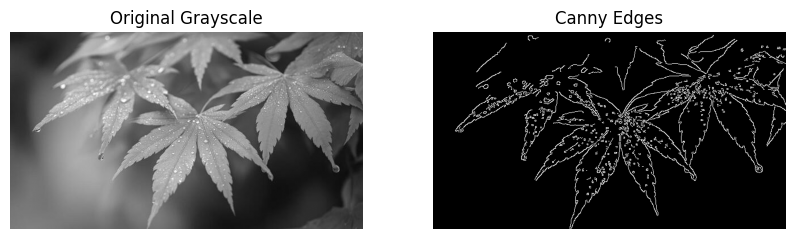

In [9]:
# TODO 6:
# Perform edge detection using cv2.Canny

edges = cv2.Canny(img_cv_gray, 100, 200)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(img_cv_gray, cmap='gray'); plt.title("Original Grayscale"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(edges, cmap='gray'); plt.title("Canny Edges"); plt.axis('off')
plt.show()

- OpenCV is easiest for real-time/video processing due to its efficient C++ backend
- OpenCV would be chosen for real-time video processing
- RGB and BGR differ in the order of color channels - RGB is Red-Green-Blue while BGR is Blue-Green-Red (OpenCV's default)